In [1]:
import pandas as pd
import numpy as np


In [2]:
#!wget https://github.com/durveshcollegeid/sem5_ML/blob/main/aug28/adult/adult.data

In [3]:
path = "/content/adult.data"

In [4]:
df = pd.read_csv( path )
df_backup = pd.read_csv( path )

In [5]:
col_list = [ "age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income" ]

In [6]:
df.columns = col_list
df_backup.columns = col_list

Drop unnecessary columns

In [7]:
df = df.drop( "fnlwgt", axis=1 )

OneHotEncoding

In [8]:
#targeted_cols = [ "workclass", "marital-status", "occupation", "relationship", "race", "sex", "native-country" ]
targeted_cols = [ "workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country" ]

In [9]:
df = pd.get_dummies(df, columns=targeted_cols, dtype=int)

Splitting into features and target

In [10]:
y = df[ "income" ]
X = df.drop( "income", axis=1 )

Splitting into test and train

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

Scaling Numeric data for X_train only

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
for col in X_train :
  if( X_train[col].dtype == "int64" or X_train[col].dtype == "float64" ) :
    scaler = StandardScaler()
    X_train[col] = scaler.fit_transform( np.array(X_train[col]).reshape(-1,1) )


Importing KNN model

In [15]:
from sklearn.neighbors import KNeighborsClassifier

Instantiating teh model without any arguments

In [16]:
knn_model = KNeighborsClassifier(  )

Define a dictionary of chosen parameters for the knn model

In [17]:
knn_params = {
    "n_neighbors" : [ 3, 5, 7, 9, 11 ],
    "weights" : [ "uniform", "distance" ],
    #"metric" : [ "euclidean", "manhattan", "minkowski" ],
    #"algorithm" : [ "auto", "ball_tree", "kd_tree", "brute" ]
    #"p" : [ 1, 2 ] #-> p is the power parameter used in the Minkowski distance metric
}



Instantiating a cross-validator based on dictionary of chosen parameters

In [18]:
from sklearn.model_selection import GridSearchCV

In [19]:
knn_grid = GridSearchCV( knn_model, knn_params, cv=5, scoring="accuracy", n_jobs=-1 )

Fit the cross validatoron the training data

In [20]:
knn_grid.fit( X_train, y_train )

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

Obtain best parameters

In [21]:
print( f"Best parameters : { knn_grid.best_params_ }" )

Best parameters : {'n_neighbors': 9, 'weights': 'uniform'}


In [22]:
print( f"Best CV score : { knn_grid.best_score_ }" )

Best CV score : 0.8303901007005077


Use "best estimator" to predict labels on the test data

In [31]:
knn_best = knn_grid.best_estimator_

In [32]:
y_pred = knn_best.predict( X_test )

Add pie chart to visualize performance

In [25]:
from sklearn.metrics import accuracy_score

In [33]:
knn_acc = accuracy_score( y_test, y_pred )

In [28]:
import matplotlib.pyplot as plt

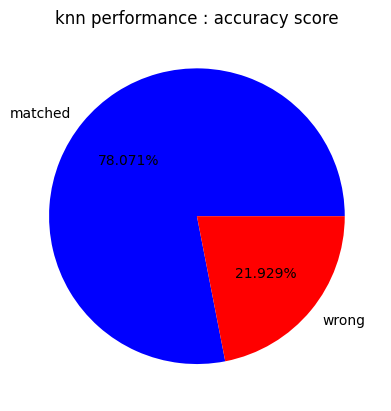

In [34]:
#plt.subplot( 1, 2, 1 )
plt.pie(
    x=[ knn_acc*100, 100 - (knn_acc)*100 ],
    labels=["matched", "wrong"],
    autopct='%1.3f%%',   # Formats the percentage to 1 decimal place
    colors=[ "blue", "red" ],       # Applies custom colors
    #pctdistance=0.85     # Adjusts the position of the percentage text
)
plt.title( "knn performance : accuracy score" )

plt.show()
